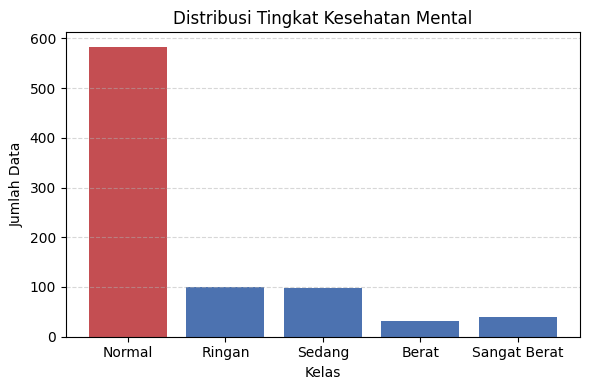

In [2]:
import matplotlib.pyplot as plt

kelas = ["Normal", "Ringan", "Sedang", "Berat", "Sangat Berat"]
jumlah = [583, 100, 98, 32, 39]

plt.figure(figsize=(6,4))

colors = ["#4C72B0"] * len(kelas)  # semua biru
colors[0] = "#C44E52"  # highlight kelas dominan

plt.bar(kelas, jumlah, color=colors)

plt.title("Distribusi Tingkat Kesehatan Mental")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

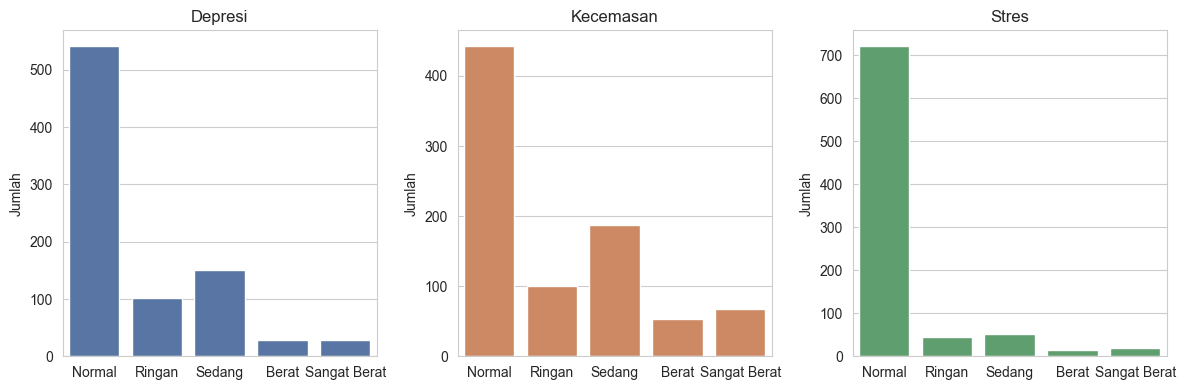

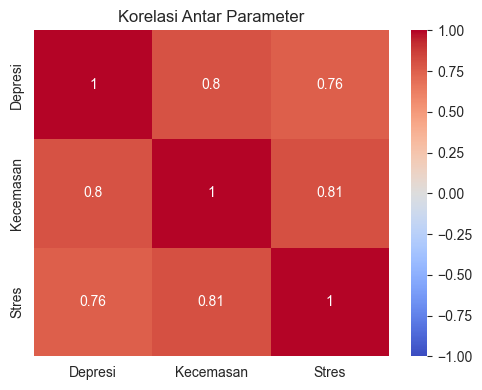

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data_uji_reliabilitas_validitas.csv")

depresi = ["D1","D2","D3","D4","D5","D6","D7"]
kecemasan = ["A1","A2","A3","A4","A5","A6","A7"]
stres = ["S1","S2","S3","S4","S5","S6","S7"]

# ===============================
# HITUNG SKOR TOTAL
# ===============================
df["Depresi"] = df[depresi].sum(axis=1)
df["Kecemasan"] = df[kecemasan].sum(axis=1)
df["Stres"] = df[stres].sum(axis=1)

# ===============================
# KATEGORI (SESUAI TABEL KAMU)
# ===============================
def kategori_dep(x):
    if x <= 6: return "Normal"
    elif x <= 8: return "Ringan"
    elif x <= 13: return "Sedang"
    elif x <= 16: return "Berat"
    else: return "Sangat Berat"

def kategori_kec(x):
    if x <= 5: return "Normal"
    elif x <= 7: return "Ringan"
    elif x <= 12: return "Sedang"
    elif x <= 15: return "Berat"
    else: return "Sangat Berat"

def kategori_str(x):
    if x <= 11: return "Normal"
    elif x <= 13: return "Ringan"
    elif x <= 16: return "Sedang"
    elif x <= 18: return "Berat"
    else: return "Sangat Berat"

df["Depresi_kat"] = df["Depresi"].apply(kategori_dep)
df["Kecemasan_kat"] = df["Kecemasan"].apply(kategori_kec)
df["Stres_kat"] = df["Stres"].apply(kategori_str)

order = ["Normal","Ringan","Sedang","Berat","Sangat Berat"]

# ===============================
# DISTRIBUSI PARAMETER (SUBPLOT)
# ===============================
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.countplot(data=df, x="Depresi_kat", order=order, ax=axes[0], color="#4C72B0")
sns.countplot(data=df, x="Kecemasan_kat", order=order, ax=axes[1], color="#DD8452")
sns.countplot(data=df, x="Stres_kat", order=order, ax=axes[2], color="#55A868")

axes[0].set_title("Depresi")
axes[1].set_title("Kecemasan")
axes[2].set_title("Stres")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

# ===============================
# KORELASI PARAMETER
# ===============================
corr = df[["Depresi","Kecemasan","Stres"]].corr()

plt.figure(figsize=(5,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Korelasi Antar Parameter")
plt.tight_layout()
plt.show()

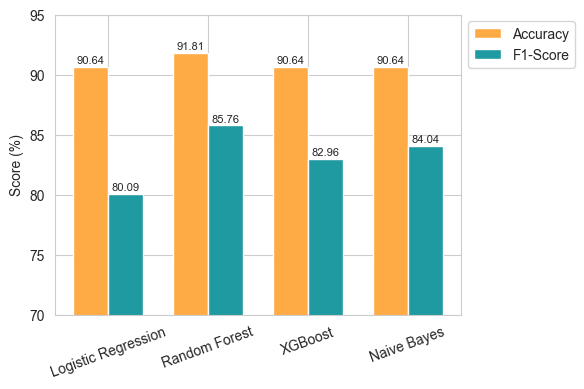

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Random Forest", "XGBoost", "Naive Bayes"]

accuracy = [90.64, 91.81, 90.64, 90.64]
f1 = [80.09, 85.76, 82.96, 84.04]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,4))

# 🎨 warna sesuai palette
color_acc = "#FFAB45"   # kuning
color_f1  = "#209AA1"   # teal

bars1 = plt.bar(x - width/2, accuracy, width, label="Accuracy", color=color_acc)
bars2 = plt.bar(x + width/2, f1, width, label="F1-Score", color=color_f1)

plt.xticks(x, models, rotation=20)
plt.ylabel("Score (%)")
plt.ylim(70, 95)

# 🔥 legend keluar biar clean
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# label angka
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.3,
                 f"{height:.2f}",
                 ha='center',
                 fontsize=8)

# 🔥 kasih space kanan untuk legend
plt.tight_layout(rect=[0,0,0.85,1])

plt.show()

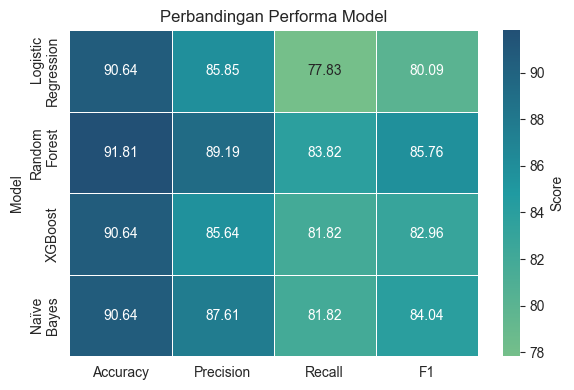

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

data = {
    "Model": [
        "Logistic\nRegression",
        "Random\nForest",
        "XGBoost",
        "Naïve\nBayes"
    ],
    "Accuracy": [90.64, 91.81, 90.64, 90.64],
    "Precision": [85.85, 89.19, 85.64, 87.61],
    "Recall": [77.83, 83.82, 81.82, 81.82],
    "F1": [80.09, 85.76, 82.96, 84.04]
}

df = pd.DataFrame(data).set_index("Model")

# 🎨 custom gradient dari palette kamu
colors = ["#75BF8A", "#209AA1", "#225075"]
custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(6,4))

sns.heatmap(
    df,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Score"}
)

plt.title("Perbandingan Performa Model")
plt.tight_layout()
plt.show()